In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use("seaborn-v0_8-darkgrid")

In [11]:
# Parameters
S0 = 100          # spot today
K  = 100          # strike
r  = 0.05         # risk-free rate
T  = 1.0          # years
implied_div = 5   # PV of dividends implied in market pricing

# Grid of terminal stock prices
ST = np.linspace(50, 150, 201)

# Present value of strike
PV_K = K * np.exp(-r * T)

In [12]:
# Payoff functions at maturity

def call_payoff(ST, K):
    return np.maximum(ST - K, 0.0)

def put_payoff(ST, K):
    return np.maximum(K - ST, 0.0)

def stock_payoff(ST, S0):
    return ST - S0

# Four legs of the strategy
call_leg    =  call_payoff(ST, K)      # long call
put_leg     = -put_payoff(ST, K)       # short put
stock_leg   = -stock_payoff(ST, S0)    # short stock
lending_leg =  np.full_like(ST, PV_K)  # lend PV(K) at risk-free rate [FIX: added lending leg]

strategy_payoff = call_leg + put_leg + stock_leg + lending_leg

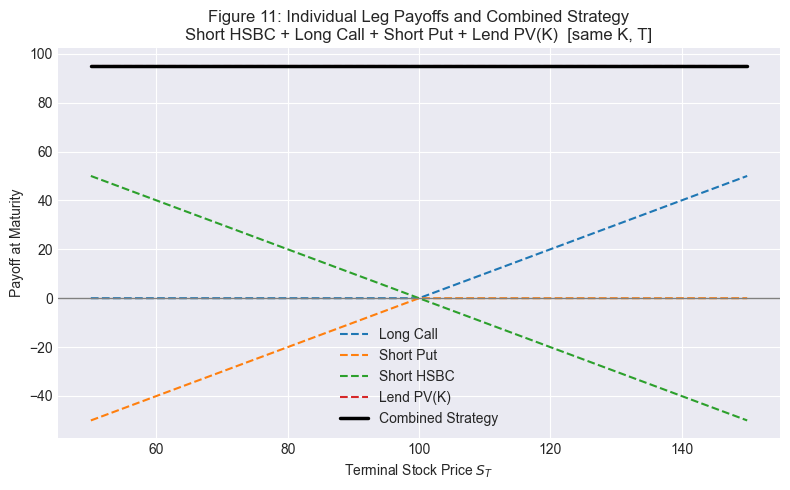

In [21]:
# Figure 1: Strategy payoff decomposition

plt.figure(figsize=(8, 5))
plt.plot(ST, call_leg,    "--", label="Long Call",  linewidth=1.5)
plt.plot(ST, put_leg,     "--", label="Short Put",  linewidth=1.5)
plt.plot(ST, stock_leg,   "--", label="Short HSBC", linewidth=1.5)
plt.plot(ST, lending_leg, "--", label="Lend PV(K)", linewidth=1.5)
plt.plot(ST, strategy_payoff, "k", lw=2.5, label="Combined Strategy")
plt.axhline(0, color="gray", lw=1)
plt.xlabel("Terminal Stock Price $S_T$")
plt.ylabel("Payoff at Maturity")
plt.title("Figure 11: Individual Leg Payoffs and Combined Strategy\n"
          "Short HSBC + Long Call + Short Put + Lend PV(K)  [same K, T]")
plt.legend()
plt.tight_layout()
plt.show()

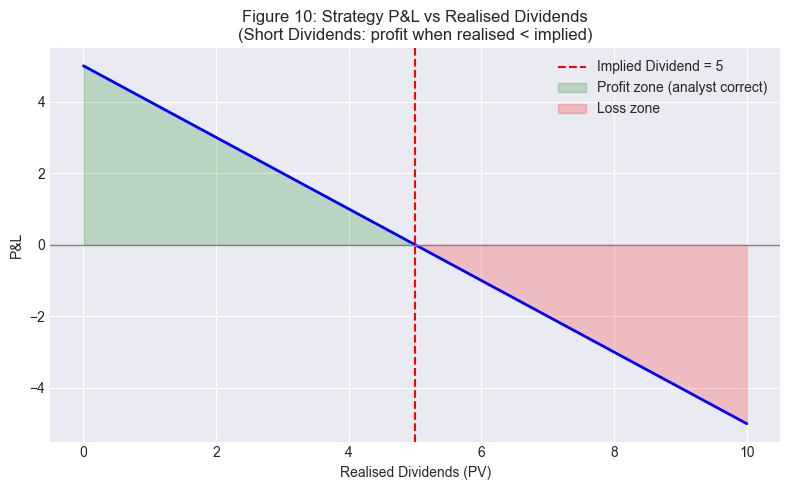

In [20]:
# Figure 2: P&L vs realised dividends

realised_divs = np.linspace(0, 10, 101)
pnl_vs_div = implied_div - realised_divs  # long dividends: profit when realised < implied

plt.figure(figsize=(8, 5))
plt.plot(realised_divs, pnl_vs_div, "b", lw=2)
plt.axhline(0, color="gray", lw=1)
plt.axvline(implied_div, color="red", linestyle="--", lw=1.5,
            label=f"Implied Dividend = {implied_div}")
plt.fill_between(realised_divs, pnl_vs_div, 0,
                 where=(realised_divs < implied_div),
                 color="green", alpha=0.2, label="Profit zone (analyst correct)")
plt.fill_between(realised_divs, pnl_vs_div, 0,
                 where=(realised_divs > implied_div),
                 color="red", alpha=0.2, label="Loss zone")
plt.xlabel("Realised Dividends (PV)")
plt.ylabel("P&L")
# [FIX: corrected title — strategy is LONG dividends, not short]
plt.title("Figure 10: Strategy P&L vs Realised Dividends\n"
          "(Short Dividends: profit when realised < implied)")
plt.legend()
plt.tight_layout()
plt.show()

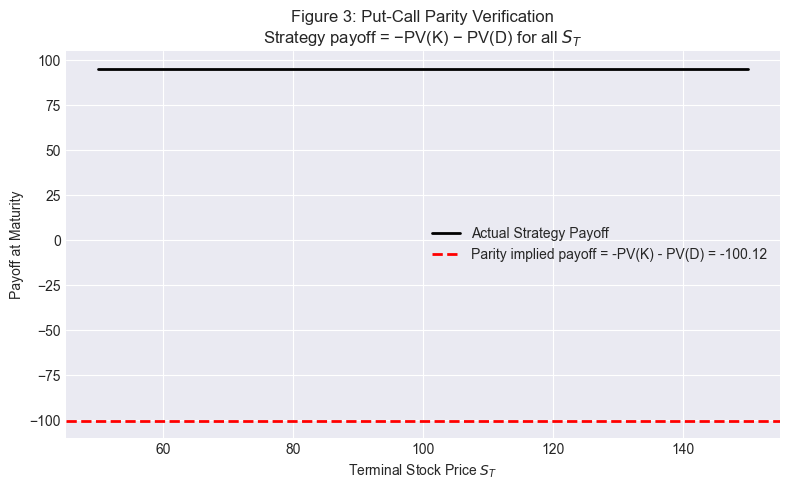

In [15]:
# Figure 3: Put-call parity verification

parity_line = -PV_K - implied_div

plt.figure(figsize=(8, 5))
plt.plot(ST, strategy_payoff, "k", lw=2, label="Actual Strategy Payoff")
plt.axhline(parity_line, color="red", lw=2, linestyle="--",
            label=f"Parity implied payoff = -PV(K) - PV(D) = {parity_line:.2f}")
plt.xlabel("Terminal Stock Price $S_T$")
plt.ylabel("Payoff at Maturity")
plt.title("Figure 3: Put-Call Parity Verification\n"
          "Strategy payoff = −PV(K) − PV(D) for all $S_T$")
plt.legend()
plt.tight_layout()
plt.show()

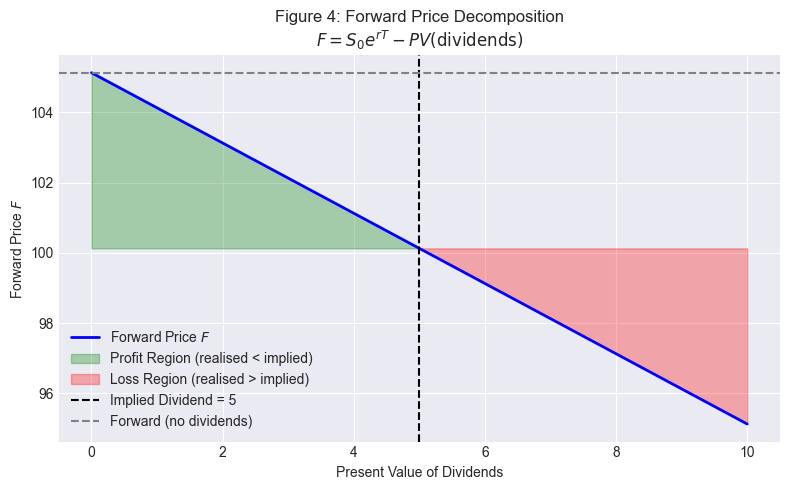

In [16]:
# Figure 4: Forward price decomposition

dividends = np.linspace(0, 10, 200)
forward_prices = S0 * np.exp(r * T) - dividends
no_div_forward = S0 * np.exp(r * T)
implied_forward = no_div_forward - implied_div

plt.figure(figsize=(8, 5))
plt.plot(dividends, forward_prices, color="blue", lw=2, label="Forward Price $F$")
plt.fill_between(dividends, forward_prices, implied_forward,
                 where=(dividends < implied_div),
                 color="green", alpha=0.3, label="Profit Region (realised < implied)")
plt.fill_between(dividends, forward_prices, implied_forward,
                 where=(dividends > implied_div),
                 color="red", alpha=0.3, label="Loss Region (realised > implied)")
plt.axvline(implied_div, color="black", linestyle="--",
            label=f"Implied Dividend = {implied_div}")
plt.axhline(no_div_forward, color="gray", linestyle="--", label="Forward (no dividends)")
plt.xlabel("Present Value of Dividends")
plt.ylabel("Forward Price $F$")
plt.title("Figure 4: Forward Price Decomposition\n"
          "$F = S_0 e^{rT} - PV(\\mathrm{dividends})$")
plt.legend()
plt.tight_layout()
plt.show()

Expected P&L:          0.0008
5th-95th percentile:   [-2.8322, 2.0749]
Probability of profit: 56.0%


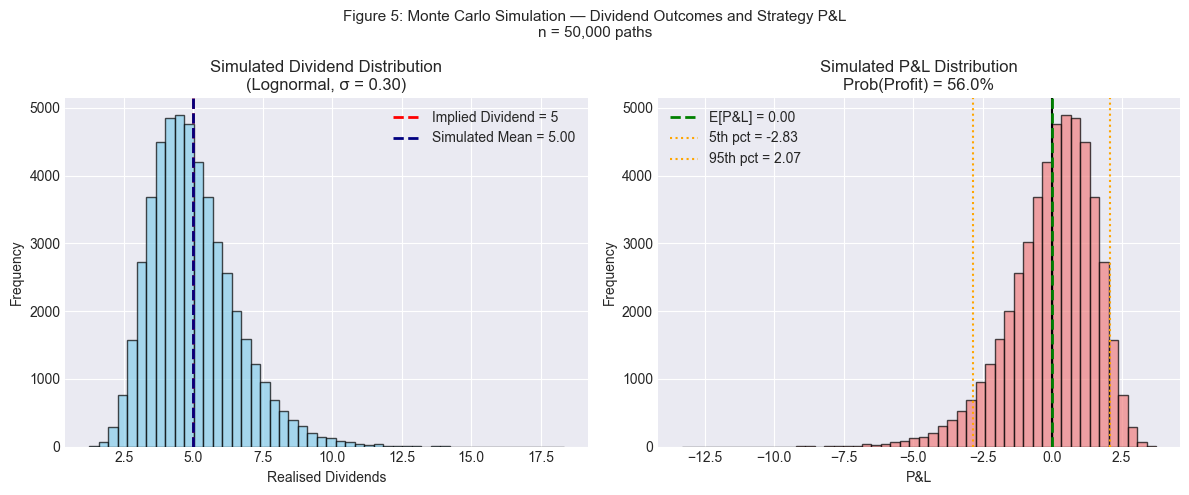

In [17]:
# Figure 5: Monte Carlo simulation of dividend outcomes and P&L

np.random.seed(42)
n_paths = 50_000
mu    = np.log(implied_div) - 0.5 * 0.3**2  # [FIX: correct lognormal mean adjustment]
sigma = 0.3
simulated_dividends = np.random.lognormal(mean=mu, sigma=sigma, size=n_paths)

# [FIX: compute P&L statistics]
pnl_simulated = implied_div - simulated_dividends
expected_pnl  = pnl_simulated.mean()
pct5, pct95   = np.percentile(pnl_simulated, [5, 95])
prob_profit   = (pnl_simulated > 0).mean() * 100

print(f"Expected P&L:          {expected_pnl:.4f}")
print(f"5th-95th percentile:   [{pct5:.4f}, {pct95:.4f}]")
print(f"Probability of profit: {prob_profit:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(simulated_dividends, bins=50, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].axvline(implied_div, color="red", linestyle="--", lw=2,
                label=f"Implied Dividend = {implied_div}")
axes[0].axvline(simulated_dividends.mean(), color="navy", linestyle="--", lw=2,
                label=f"Simulated Mean = {simulated_dividends.mean():.2f}")
axes[0].set_xlabel("Realised Dividends")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Simulated Dividend Distribution\n(Lognormal, σ = 0.30)")
axes[0].legend()

axes[1].hist(pnl_simulated, bins=50, color="lightcoral", edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="black", lw=1.5)
axes[1].axvline(expected_pnl, color="green", linestyle="--", lw=2,
                label=f"E[P&L] = {expected_pnl:.2f}")
axes[1].axvline(pct5,  color="orange", linestyle=":", lw=1.5, label=f"5th pct = {pct5:.2f}")
axes[1].axvline(pct95, color="orange", linestyle=":", lw=1.5, label=f"95th pct = {pct95:.2f}")
axes[1].set_xlabel("P&L")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Simulated P&L Distribution\nProb(Profit) = {prob_profit:.1f}%")
axes[1].legend()

fig.suptitle(f"Figure 5: Monte Carlo Simulation — Dividend Outcomes and Strategy P&L\n"
             f"n = {n_paths:,} paths", fontsize=11)
fig.tight_layout()
plt.show()

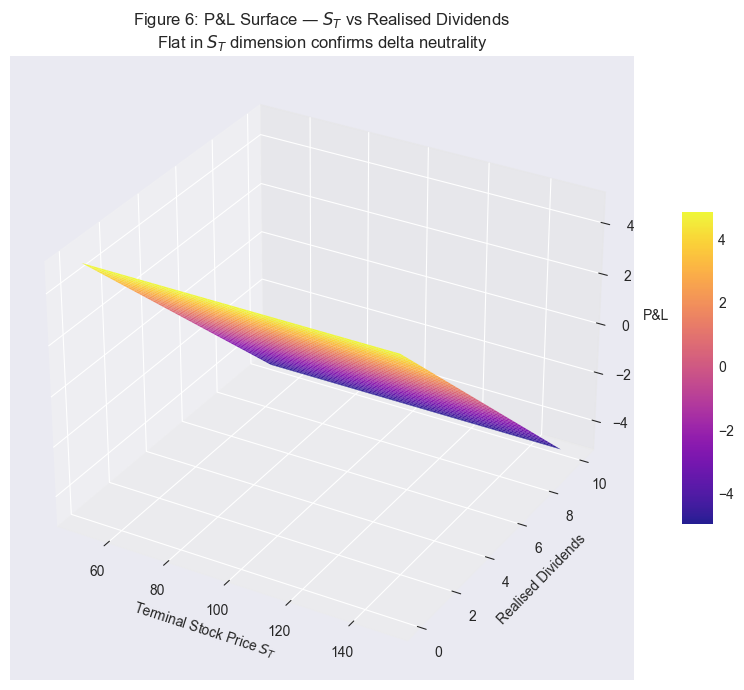

In [18]:
# Figure 6: 3D P&L surface

ST_grid, div_grid = np.meshgrid(ST, realised_divs)
pnl_grid = implied_div - div_grid  # independent of ST

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(ST_grid, div_grid, pnl_grid, cmap="plasma",
                       edgecolor="none", alpha=0.9)
# [FIX: corrected axis label typos]
ax.set_xlabel("Terminal Stock Price $S_T$")
ax.set_ylabel("Realised Dividends")
ax.set_zlabel("P&L")
ax.set_title("Figure 6: P&L Surface — $S_T$ vs Realised Dividends\n"
             "Flat in $S_T$ dimension confirms delta neutrality")
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()